In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import random

In [2]:
base_dir = os.path.join(os.getcwd(), "tests", "data", "pottery", "decoration")
dir_impressed = os.path.join(base_dir, "impressed")
dir_incised = os.path.join(base_dir, "incised")

Loaded 50 images
Impressed: 25
Incised: 25


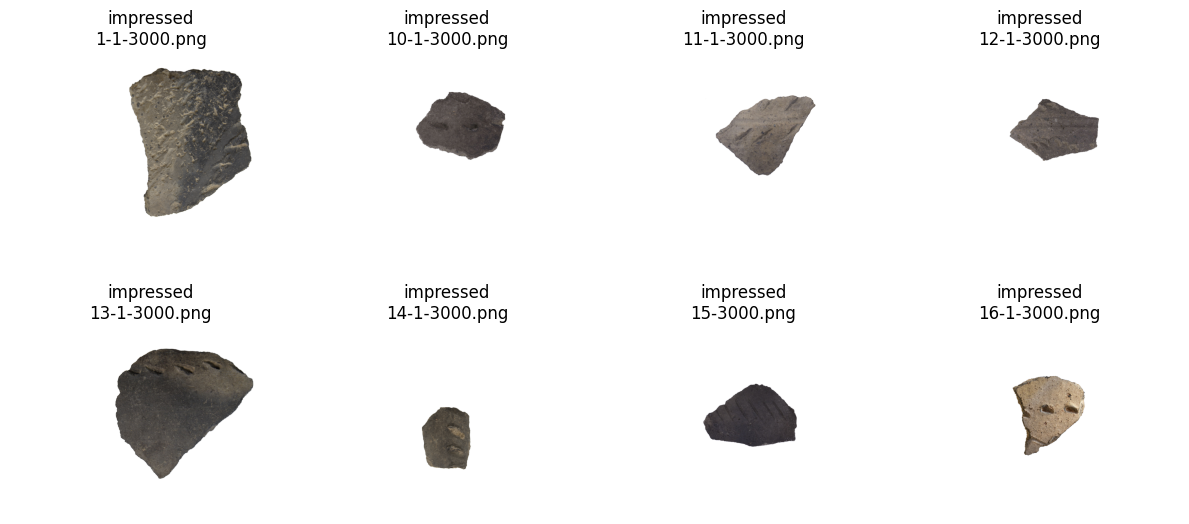

In [4]:
# Data Loading and Preprocessing
import os
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up paths
# go up one level from the current directory
base_dir = os.path.join(os.getcwd(), "..")
base_dir = os.path.join(base_dir, "tests", "data", "pottery", "decoration")
impressed_dir = os.path.join(base_dir, "impressed")
incised_dir = os.path.join(base_dir, "incised")

# Load all images with labels
def load_pottery_images():
    """Load all pottery images with their labels"""
    images = []
    labels = []
    filenames = []
    
    # Load impressed images
    impressed_files = glob.glob(os.path.join(impressed_dir, "*.png"))
    for file_path in sorted(impressed_files):
        try:
            img = Image.open(file_path)
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            images.append(img)
            labels.append('impressed')
            filenames.append(os.path.basename(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Load incised images
    incised_files = glob.glob(os.path.join(incised_dir, "*.png"))
    for file_path in sorted(incised_files):
        try:
            img = Image.open(file_path)
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            images.append(img)
            labels.append('incised')
            filenames.append(os.path.basename(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return images, labels, filenames

# Load the data
images, labels, filenames = load_pottery_images()
print(f"Loaded {len(images)} images")
print(f"Impressed: {labels.count('impressed')}")
print(f"Incised: {labels.count('incised')}")

# Display sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(images[i])
    axes[row, col].set_title(f"{labels[i]}\n{filenames[i]}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Pre-trained Model Feature Extractors
import torch
import torch.nn as nn
from torchvision import transforms, models
from transformers import AutoImageProcessor, AutoModel
import timm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Image preprocessing
def preprocess_image(image, size=224):
    """Convert PIL image to tensor for model input"""
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image.convert('RGB'))

# DINOv2 Feature Extractor
class DINOv2Extractor:
    def __init__(self, model_name='dinov2_vits14'):
        self.model_name = model_name
        self.model = torch.hub.load('facebookresearch/dinov2', model_name)
        self.model.eval()
        self.model.to(device)
        
    def extract_features(self, images):
        """Extract features from list of PIL images"""
        features = []
        with torch.no_grad():
            for img in images:
                # Preprocess image
                img_tensor = preprocess_image(img).unsqueeze(0).to(device)
                
                # Extract features
                features_tensor = self.model(img_tensor)
                features.append(features_tensor.cpu().numpy().flatten())
        
        return np.array(features)

# CLIP Feature Extractor
class CLIPExtractor:
    def __init__(self, model_name='openai/clip-vit-base-patch16'):
        from transformers import CLIPProcessor, CLIPModel
        self.model = CLIPModel.from_pretrained(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model.eval()
        self.model.to(device)
        
    def extract_features(self, images):
        """Extract features from list of PIL images"""
        features = []
        with torch.no_grad():
            for img in images:
                # Preprocess image
                inputs = self.processor(images=img, return_tensors="pt").to(device)
                
                # Extract features
                image_features = self.model.get_image_features(**inputs)
                features.append(image_features.cpu().numpy().flatten())
        
        return np.array(features)

# ResNet50 Feature Extractor
class ResNet50Extractor:
    def __init__(self):
        self.model = models.resnet50(pretrained=True)
        self.model = nn.Sequential(*list(self.model.children())[:-1])  # Remove final FC layer
        self.model.eval()
        self.model.to(device)
        
    def extract_features(self, images):
        """Extract features from list of PIL images"""
        features = []
        with torch.no_grad():
            for img in images:
                # Preprocess image
                img_tensor = preprocess_image(img).unsqueeze(0).to(device)
                
                # Extract features
                features_tensor = self.model(img_tensor)
                features.append(features_tensor.cpu().numpy().flatten())
        
        return np.array(features)

# Additional Pre-trained Models
class EfficientNetExtractor:
    def __init__(self, model_name='efficientnet_b4'):
        self.model = timm.create_model(model_name, pretrained=True, num_classes=0)  # Remove classifier
        self.model.eval()
        self.model.to(device)
        
    def extract_features(self, images):
        """Extract features from list of PIL images"""
        features = []
        with torch.no_grad():
            for img in images:
                # Preprocess image
                img_tensor = preprocess_image(img, size=224).unsqueeze(0).to(device)
                
                # Extract features
                features_tensor = self.model(img_tensor)
                features.append(features_tensor.cpu().numpy().flatten())
        
        return np.array(features)

# Initialize extractors
print("Initializing feature extractors...")
dinov2_extractor = DINOv2Extractor('dinov2_vits14')
clip_extractor = CLIPExtractor('openai/clip-vit-base-patch16')
resnet50_extractor = ResNet50Extractor()
efficientnet_extractor = EfficientNetExtractor('efficientnet_b4')

print("Feature extractors initialized successfully!")


In [5]:
# Hand-Engineered Feature Extractors

# Ridge/Valley Detection Features
from scipy import ndimage
from skimage import filters, feature, morphology, measure
from skimage.filters import frangi, sato
import cv2

class RidgeValleyExtractor:
    def __init__(self):
        self.sigmas = [1, 2, 4, 8]  # Multi-scale analysis
        
    def extract_features(self, images):
        """Extract ridge/valley features using Frangi and Sato filters"""
        features = []
        
        for img in images:
            # Convert to grayscale and handle transparency
            if img.mode == 'RGBA':
                # Create white background
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])  # Use alpha channel as mask
                gray = np.array(background.convert('L'))
            else:
                gray = np.array(img.convert('L'))
            
            # Normalize to 0-1
            gray = gray.astype(np.float32) / 255.0
            
            # Frangi vesselness filter
            frangi_response = frangi(gray, sigmas=self.sigmas, beta1=0.5, beta2=15)
            
            # Sato filter for line enhancement
            sato_response = sato(gray, sigmas=self.sigmas, black_ridges=False)
            
            # Extract statistics
            feature_vector = []
            
            # Frangi statistics
            feature_vector.extend([
                np.mean(frangi_response),
                np.std(frangi_response),
                np.max(frangi_response),
                np.percentile(frangi_response, 95),
                np.sum(frangi_response > 0.1) / frangi_response.size,  # Percentage above threshold
            ])
            
            # Sato statistics
            feature_vector.extend([
                np.mean(sato_response),
                np.std(sato_response),
                np.max(sato_response),
                np.percentile(sato_response, 95),
                np.sum(sato_response > 0.1) / sato_response.size,
            ])
            
            # Multi-scale analysis
            for sigma in self.sigmas:
                frangi_single = frangi(gray, sigmas=[sigma], beta1=0.5, beta2=15)
                sato_single = sato(gray, sigmas=[sigma], black_ridges=False)
                
                feature_vector.extend([
                    np.mean(frangi_single),
                    np.std(frangi_single),
                    np.mean(sato_single),
                    np.std(sato_single),
                ])
            
            features.append(feature_vector)
        
        return np.array(features)

# Gradient-Based Features
class GradientExtractor:
    def __init__(self):
        pass
        
    def extract_features(self, images):
        """Extract gradient-based features"""
        features = []
        
        for img in images:
            # Convert to grayscale
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])
                gray = np.array(background.convert('L'))
            else:
                gray = np.array(img.convert('L'))
            
            # Sobel gradients
            grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
            grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
            grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
            grad_direction = np.arctan2(grad_y, grad_x)
            
            # Gradient statistics
            feature_vector = [
                np.mean(grad_magnitude),
                np.std(grad_magnitude),
                np.max(grad_magnitude),
                np.percentile(grad_magnitude, 95),
                np.sum(grad_magnitude > np.percentile(grad_magnitude, 80)) / grad_magnitude.size,
            ]
            
            # Directional gradient histograms (8 bins)
            hist, _ = np.histogram(grad_direction, bins=8, range=(-np.pi, np.pi))
            feature_vector.extend(hist / np.sum(hist))  # Normalized histogram
            
            # Distance transform features
            # Create binary image for distance transform
            binary = gray > np.percentile(gray, 50)  # Threshold
            dist_transform = cv2.distanceTransform(binary.astype(np.uint8), cv2.DIST_L2, 5)
            
            feature_vector.extend([
                np.mean(dist_transform),
                np.std(dist_transform),
                np.max(dist_transform),
                np.percentile(dist_transform, 95),
            ])
            
            # Skeleton-based features
            skeleton = morphology.skeletonize(binary)
            if np.sum(skeleton) > 0:
                # Groove width statistics
                dist_to_skeleton = cv2.distanceTransform((~skeleton).astype(np.uint8), cv2.DIST_L2, 5)
                feature_vector.extend([
                    np.mean(dist_to_skeleton[skeleton]),
                    np.std(dist_to_skeleton[skeleton]),
                    np.max(dist_to_skeleton[skeleton]),
                ])
            else:
                feature_vector.extend([0, 0, 0])
            
            features.append(feature_vector)
        
        return np.array(features)

# Initialize extractors
ridge_valley_extractor = RidgeValleyExtractor()
gradient_extractor = GradientExtractor()

print("Hand-engineered feature extractors initialized!")


Hand-engineered feature extractors initialized!


In [6]:
# Texture Features (LBP, GLCM, Gabor)

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import gabor
from skimage import exposure

class LBPExtractor:
    def __init__(self, radius=1, n_points=8):
        self.radius = radius
        self.n_points = n_points
        
    def extract_features(self, images):
        """Extract Local Binary Pattern features"""
        features = []
        
        for img in images:
            # Convert to grayscale
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])
                gray = np.array(background.convert('L'))
            else:
                gray = np.array(img.convert('L'))
            
            # LBP with different parameters
            feature_vector = []
            
            # Standard LBP
            lbp = local_binary_pattern(gray, self.n_points, self.radius, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=self.n_points + 2, range=(0, self.n_points + 2))
            hist = hist.astype(float)
            hist /= (hist.sum() + 1e-7)  # Normalize
            feature_vector.extend(hist)
            
            # Multi-scale LBP
            for radius in [1, 2, 3]:
                for n_points in [8, 16]:
                    lbp_ms = local_binary_pattern(gray, n_points, radius, method='uniform')
                    hist_ms, _ = np.histogram(lbp_ms.ravel(), bins=n_points + 2, range=(0, n_points + 2))
                    hist_ms = hist_ms.astype(float)
                    hist_ms /= (hist_ms.sum() + 1e-7)
                    feature_vector.extend(hist_ms)
            
            # LBP variance
            lbp_var = local_binary_pattern(gray, self.n_points, self.radius, method='var')
            feature_vector.extend([
                np.mean(lbp_var),
                np.std(lbp_var),
                np.max(lbp_var),
                np.percentile(lbp_var, 95),
            ])
            
            features.append(feature_vector)
        
        return np.array(features)

class GLCMExtractor:
    def __init__(self, distances=[1, 2, 4], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
        self.distances = distances
        self.angles = angles
        
    def extract_features(self, images):
        """Extract Gray-Level Co-occurrence Matrix features"""
        features = []
        
        for img in images:
            # Convert to grayscale
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])
                gray = np.array(background.convert('L'))
            else:
                gray = np.array(img.convert('L'))
            
            # Quantize to 32 levels for GLCM
            gray_quantized = exposure.rescale_intensity(gray, out_range=(0, 31)).astype(np.uint8)
            
            feature_vector = []
            
            # Compute GLCM for different distances and angles
            for distance in self.distances:
                for angle in self.angles:
                    glcm = graycomatrix(gray_quantized, distances=[distance], angles=[angle], 
                                      levels=32, symmetric=True, normed=True)
                    
                    # Extract texture properties
                    contrast = graycoprops(glcm, 'contrast')[0, 0]
                    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
                    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
                    energy = graycoprops(glcm, 'energy')[0, 0]
                    correlation = graycoprops(glcm, 'correlation')[0, 0]
                    asm = graycoprops(glcm, 'ASM')[0, 0]
                    
                    feature_vector.extend([contrast, dissimilarity, homogeneity, energy, correlation, asm])
            
            features.append(feature_vector)
        
        return np.array(features)

class GaborExtractor:
    def __init__(self, frequencies=[0.1, 0.2, 0.4], orientations=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
        self.frequencies = frequencies
        self.orientations = orientations
        
    def extract_features(self, images):
        """Extract Gabor filter features"""
        features = []
        
        for img in images:
            # Convert to grayscale
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])
                gray = np.array(background.convert('L'))
            else:
                gray = np.array(img.convert('L'))
            
            # Normalize
            gray = gray.astype(np.float32) / 255.0
            
            feature_vector = []
            
            # Apply Gabor filters with different parameters
            for frequency in self.frequencies:
                for orientation in self.orientations:
                    # Real and imaginary parts
                    real, imag = gabor(gray, frequency=frequency, theta=orientation)
                    
                    # Magnitude and phase
                    magnitude = np.sqrt(real**2 + imag**2)
                    phase = np.arctan2(imag, real)
                    
                    # Extract statistics
                    feature_vector.extend([
                        np.mean(magnitude),
                        np.std(magnitude),
                        np.max(magnitude),
                        np.percentile(magnitude, 95),
                        np.sum(magnitude > np.percentile(magnitude, 80)) / magnitude.size,
                    ])
                    
                    feature_vector.extend([
                        np.mean(phase),
                        np.std(phase),
                    ])
            
            # Multi-scale Gabor features
            for sigma in [1, 2, 4]:
                for frequency in [0.1, 0.2]:
                    for orientation in [0, np.pi/2]:
                        real, imag = gabor(gray, frequency=frequency, theta=orientation, sigma_x=sigma, sigma_y=sigma)
                        magnitude = np.sqrt(real**2 + imag**2)
                        
                        feature_vector.extend([
                            np.mean(magnitude),
                            np.std(magnitude),
                        ])
            
            features.append(feature_vector)
        
        return np.array(features)

# Initialize texture extractors
lbp_extractor = LBPExtractor()
glcm_extractor = GLCMExtractor()
gabor_extractor = GaborExtractor()

print("Texture feature extractors initialized!")


Texture feature extractors initialized!


In [7]:
# Clustering Algorithms and Evaluation Metrics

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

class ClusteringEvaluator:
    def __init__(self):
        self.scaler = StandardScaler()
        
    def evaluate_clustering(self, features, labels, method_name):
        """Evaluate clustering performance with multiple algorithms"""
        results = {}
        
        # Normalize features
        features_scaled = self.scaler.fit_transform(features)
        
        # Clustering algorithms
        algorithms = {
            'KMeans': KMeans(n_clusters=2, random_state=42, n_init=10),
            'Agglomerative': AgglomerativeClustering(n_clusters=2),
            'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
        }
        
        for alg_name, algorithm in algorithms.items():
            try:
                # Fit clustering
                cluster_labels = algorithm.fit_predict(features_scaled)
                
                # Handle DBSCAN noise points
                if alg_name == 'DBSCAN':
                    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
                    if n_clusters < 2:
                        # Skip if not enough clusters found
                        continue
                
                # Unsupervised metrics
                if len(set(cluster_labels)) > 1:  # Need at least 2 clusters
                    silhouette = silhouette_score(features_scaled, cluster_labels)
                    davies_bouldin = davies_bouldin_score(features_scaled, cluster_labels)
                    calinski_harabasz = calinski_harabasz_score(features_scaled, cluster_labels)
                else:
                    silhouette = davies_bouldin = calinski_harabasz = 0
                
                # Ground truth comparison
                if len(set(cluster_labels)) == 2:
                    # Find best cluster-to-label mapping
                    unique_labels = np.unique(labels)
                    unique_clusters = np.unique(cluster_labels)
                    
                    if len(unique_clusters) == 2:
                        # Try both possible mappings
                        mapping1 = {unique_clusters[0]: unique_labels[0], unique_clusters[1]: unique_labels[1]}
                        mapping2 = {unique_clusters[0]: unique_labels[1], unique_clusters[1]: unique_labels[0]}
                        
                        pred1 = [mapping1[cluster] for cluster in cluster_labels]
                        pred2 = [mapping2[cluster] for cluster in cluster_labels]
                        
                        acc1 = accuracy_score(labels, pred1)
                        acc2 = accuracy_score(labels, pred2)
                        
                        if acc1 >= acc2:
                            best_pred = pred1
                            accuracy = acc1
                        else:
                            best_pred = pred2
                            accuracy = acc2
                        
                        # Calculate other metrics
                        precision = precision_score(labels, best_pred, average='weighted')
                        recall = recall_score(labels, best_pred, average='weighted')
                        f1 = f1_score(labels, best_pred, average='weighted')
                        ari = adjusted_rand_score(labels, cluster_labels)
                        nmi = normalized_mutual_info_score(labels, cluster_labels)
                        
                        # Confusion matrix
                        cm = confusion_matrix(labels, best_pred)
                        
                    else:
                        accuracy = precision = recall = f1 = ari = nmi = 0
                        cm = np.array([[0, 0], [0, 0]])
                        best_pred = cluster_labels
                else:
                    accuracy = precision = recall = f1 = ari = nmi = 0
                    cm = np.array([[0, 0], [0, 0]])
                    best_pred = cluster_labels
                
                results[alg_name] = {
                    'cluster_labels': cluster_labels,
                    'predictions': best_pred,
                    'silhouette_score': silhouette,
                    'davies_bouldin_score': davies_bouldin,
                    'calinski_harabasz_score': calinski_harabasz,
                    'accuracy': accuracy,
                    'precision': precision,
                    'recall': recall,
                    'f1_score': f1,
                    'adjusted_rand_score': ari,
                    'normalized_mutual_info': nmi,
                    'confusion_matrix': cm
                }
                
            except Exception as e:
                print(f"Error with {alg_name} on {method_name}: {e}")
                continue
        
        return results

# Initialize evaluator
evaluator = ClusteringEvaluator()

print("Clustering evaluation system initialized!")


Clustering evaluation system initialized!


In [8]:
# Run All Experiments

print("Starting comprehensive feature extraction and clustering experiments...")
print("=" * 60)

# Store all results
all_results = {}
feature_names = []

# Pre-trained model features
print("\n1. Extracting pre-trained model features...")

try:
    print("  - DINOv2 features...")
    dinov2_features = dinov2_extractor.extract_features(images)
    dinov2_results = evaluator.evaluate_clustering(dinov2_features, labels, "DINOv2")
    all_results["DINOv2"] = dinov2_results
    feature_names.append("DINOv2")
    print(f"    DINOv2 features shape: {dinov2_features.shape}")
except Exception as e:
    print(f"    Error with DINOv2: {e}")

try:
    print("  - CLIP features...")
    clip_features = clip_extractor.extract_features(images)
    clip_results = evaluator.evaluate_clustering(clip_features, labels, "CLIP")
    all_results["CLIP"] = clip_results
    feature_names.append("CLIP")
    print(f"    CLIP features shape: {clip_features.shape}")
except Exception as e:
    print(f"    Error with CLIP: {e}")

try:
    print("  - ResNet50 features...")
    resnet50_features = resnet50_extractor.extract_features(images)
    resnet50_results = evaluator.evaluate_clustering(resnet50_features, labels, "ResNet50")
    all_results["ResNet50"] = resnet50_results
    feature_names.append("ResNet50")
    print(f"    ResNet50 features shape: {resnet50_features.shape}")
except Exception as e:
    print(f"    Error with ResNet50: {e}")

try:
    print("  - EfficientNet features...")
    efficientnet_features = efficientnet_extractor.extract_features(images)
    efficientnet_results = evaluator.evaluate_clustering(efficientnet_features, labels, "EfficientNet")
    all_results["EfficientNet"] = efficientnet_results
    feature_names.append("EfficientNet")
    print(f"    EfficientNet features shape: {efficientnet_features.shape}")
except Exception as e:
    print(f"    Error with EfficientNet: {e}")

# Hand-engineered features
print("\n2. Extracting hand-engineered features...")

try:
    print("  - Ridge/Valley features...")
    ridge_valley_features = ridge_valley_extractor.extract_features(images)
    ridge_valley_results = evaluator.evaluate_clustering(ridge_valley_features, labels, "RidgeValley")
    all_results["RidgeValley"] = ridge_valley_results
    feature_names.append("RidgeValley")
    print(f"    Ridge/Valley features shape: {ridge_valley_features.shape}")
except Exception as e:
    print(f"    Error with Ridge/Valley: {e}")

try:
    print("  - Gradient features...")
    gradient_features = gradient_extractor.extract_features(images)
    gradient_results = evaluator.evaluate_clustering(gradient_features, labels, "Gradient")
    all_results["Gradient"] = gradient_results
    feature_names.append("Gradient")
    print(f"    Gradient features shape: {gradient_features.shape}")
except Exception as e:
    print(f"    Error with Gradient: {e}")

try:
    print("  - LBP features...")
    lbp_features = lbp_extractor.extract_features(images)
    lbp_results = evaluator.evaluate_clustering(lbp_features, labels, "LBP")
    all_results["LBP"] = lbp_results
    feature_names.append("LBP")
    print(f"    LBP features shape: {lbp_features.shape}")
except Exception as e:
    print(f"    Error with LBP: {e}")

try:
    print("  - GLCM features...")
    glcm_features = glcm_extractor.extract_features(images)
    glcm_results = evaluator.evaluate_clustering(glcm_features, labels, "GLCM")
    all_results["GLCM"] = glcm_results
    feature_names.append("GLCM")
    print(f"    GLCM features shape: {glcm_features.shape}")
except Exception as e:
    print(f"    Error with GLCM: {e}")

try:
    print("  - Gabor features...")
    gabor_features = gabor_extractor.extract_features(images)
    gabor_results = evaluator.evaluate_clustering(gabor_features, labels, "Gabor")
    all_results["Gabor"] = gabor_results
    feature_names.append("Gabor")
    print(f"    Gabor features shape: {gabor_features.shape}")
except Exception as e:
    print(f"    Error with Gabor: {e}")

print(f"\nCompleted feature extraction for {len(feature_names)} methods!")
print("Feature extraction completed successfully!")


Starting comprehensive feature extraction and clustering experiments...

1. Extracting pre-trained model features...
  - DINOv2 features...
    DINOv2 features shape: (50, 384)
  - CLIP features...
    CLIP features shape: (50, 512)
  - ResNet50 features...
    ResNet50 features shape: (50, 2048)
  - EfficientNet features...
    EfficientNet features shape: (50, 1792)

2. Extracting hand-engineered features...
  - Ridge/Valley features...
    Error with Ridge/Valley: frangi() got an unexpected keyword argument 'beta1'
  - Gradient features...
    Gradient features shape: (50, 20)
  - LBP features...
Error with KMeans on LBP: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline o

Creating results summary...
Results summary shape: (14, 11)

Top 10 methods by accuracy:
   Feature_Method Cluster_Method  Accuracy  F1_Score  Silhouette_Score
1          DINOv2  Agglomerative      0.82  0.819928          0.046640
0          DINOv2         KMeans      0.78  0.779912          0.060769
3            CLIP  Agglomerative      0.72  0.718196          0.074879
2            CLIP         KMeans      0.66  0.656566          0.089579
4        ResNet50         KMeans      0.58  0.571603          0.065643
12          Gabor         KMeans      0.56  0.522569          0.433282
13          Gabor  Agglomerative      0.56  0.509804          0.455207
5        ResNet50  Agglomerative      0.54  0.416540          0.321979
6    EfficientNet         KMeans      0.54  0.530804          0.084949
7    EfficientNet  Agglomerative      0.54  0.479873          0.122073


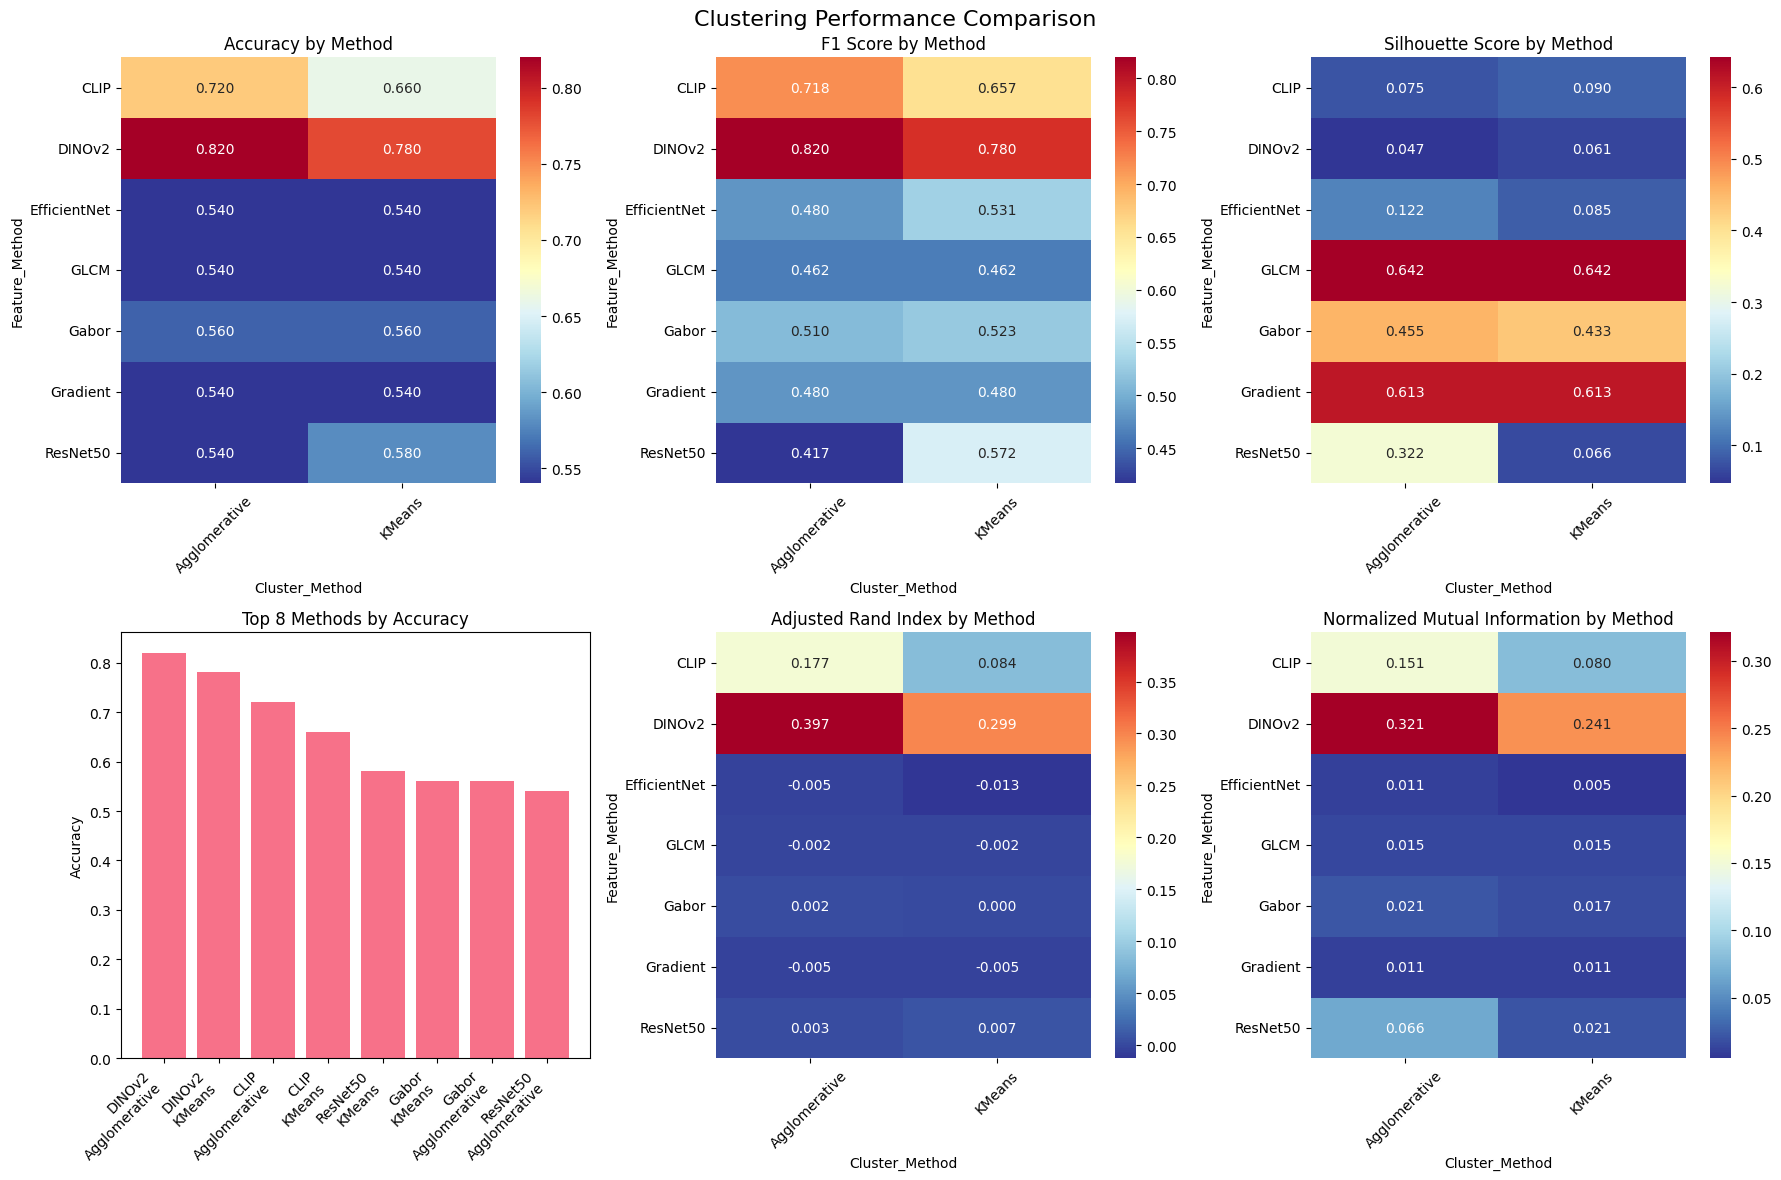

Visualization 1: Performance comparison charts created!


In [9]:
# Visualization and Analysis

from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive results summary
def create_results_summary(all_results):
    """Create a comprehensive results summary table"""
    summary_data = []
    
    for feature_method, results in all_results.items():
        for cluster_method, metrics in results.items():
            summary_data.append({
                'Feature_Method': feature_method,
                'Cluster_Method': cluster_method,
                'Silhouette_Score': metrics['silhouette_score'],
                'Davies_Bouldin_Score': metrics['davies_bouldin_score'],
                'Calinski_Harabasz_Score': metrics['calinski_harabasz_score'],
                'Accuracy': metrics['accuracy'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1_Score': metrics['f1_score'],
                'Adjusted_Rand_Score': metrics['adjusted_rand_score'],
                'Normalized_Mutual_Info': metrics['normalized_mutual_info']
            })
    
    return pd.DataFrame(summary_data)

# Create summary table
print("Creating results summary...")
summary_df = create_results_summary(all_results)
print(f"Results summary shape: {summary_df.shape}")
print("\nTop 10 methods by accuracy:")
print(summary_df.nlargest(10, 'Accuracy')[['Feature_Method', 'Cluster_Method', 'Accuracy', 'F1_Score', 'Silhouette_Score']])

# 1. Results Comparison Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Clustering Performance Comparison', fontsize=16)

# Accuracy comparison
accuracy_pivot = summary_df.pivot(index='Feature_Method', columns='Cluster_Method', values='Accuracy')
sns.heatmap(accuracy_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[0,0])
axes[0,0].set_title('Accuracy by Method')
axes[0,0].tick_params(axis='x', rotation=45)

# F1 Score comparison
f1_pivot = summary_df.pivot(index='Feature_Method', columns='Cluster_Method', values='F1_Score')
sns.heatmap(f1_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[0,1])
axes[0,1].set_title('F1 Score by Method')
axes[0,1].tick_params(axis='x', rotation=45)

# Silhouette Score comparison
silhouette_pivot = summary_df.pivot(index='Feature_Method', columns='Cluster_Method', values='Silhouette_Score')
sns.heatmap(silhouette_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[0,2])
axes[0,2].set_title('Silhouette Score by Method')
axes[0,2].tick_params(axis='x', rotation=45)

# Bar chart of best methods
best_methods = summary_df.nlargest(8, 'Accuracy')
axes[1,0].bar(range(len(best_methods)), best_methods['Accuracy'])
axes[1,0].set_title('Top 8 Methods by Accuracy')
axes[1,0].set_xticks(range(len(best_methods)))
axes[1,0].set_xticklabels([f"{row['Feature_Method']}\n{row['Cluster_Method']}" for _, row in best_methods.iterrows()], rotation=45, ha='right')
axes[1,0].set_ylabel('Accuracy')

# ARI comparison
ari_pivot = summary_df.pivot(index='Feature_Method', columns='Cluster_Method', values='Adjusted_Rand_Score')
sns.heatmap(ari_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[1,1])
axes[1,1].set_title('Adjusted Rand Index by Method')
axes[1,1].tick_params(axis='x', rotation=45)

# NMI comparison
nmi_pivot = summary_df.pivot(index='Feature_Method', columns='Cluster_Method', values='Normalized_Mutual_Info')
sns.heatmap(nmi_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[1,2])
axes[1,2].set_title('Normalized Mutual Information by Method')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualization 1: Performance comparison charts created!")


Best performing method: DINOv2 + Agglomerative
Best accuracy: 0.820
Creating t-SNE and UMAP projections...


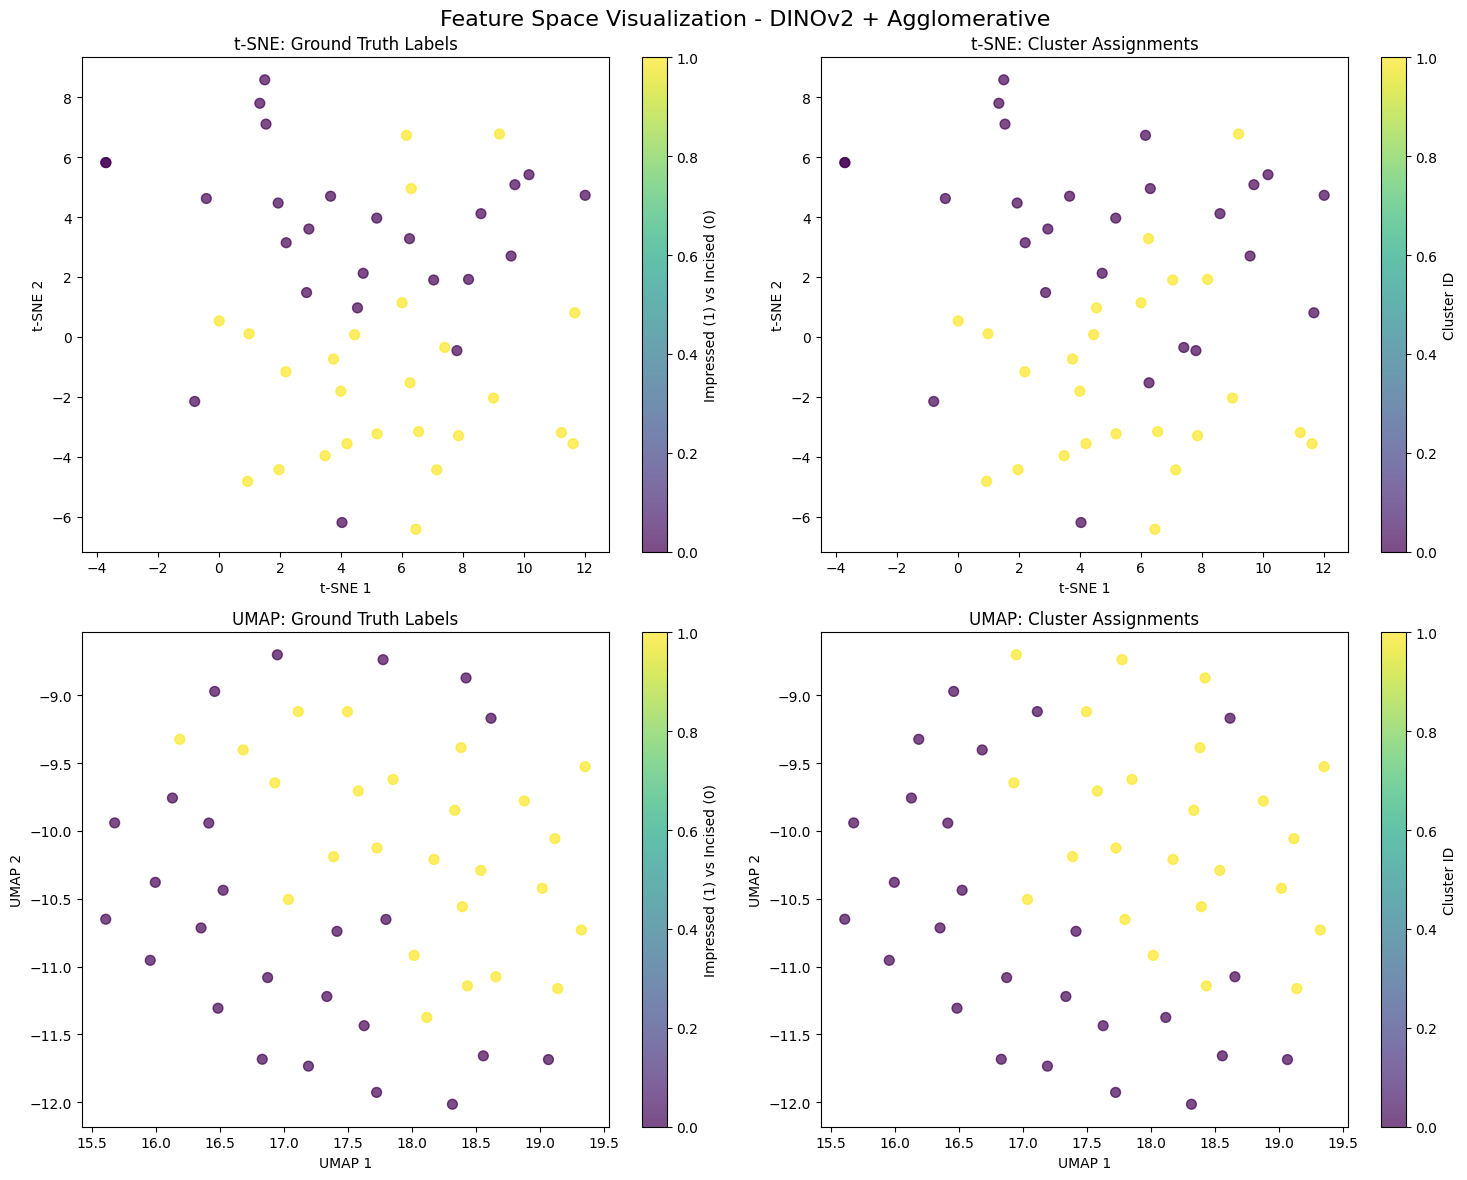

Visualization 2: t-SNE and UMAP projections created!


In [10]:
# 2. t-SNE and UMAP Projections

# Get the best performing method for visualization
best_method = summary_df.loc[summary_df['Accuracy'].idxmax()]
best_feature_method = best_method['Feature_Method']
best_cluster_method = best_method['Cluster_Method']

print(f"Best performing method: {best_feature_method} + {best_cluster_method}")
print(f"Best accuracy: {best_method['Accuracy']:.3f}")

# Get features for the best method
if best_feature_method == "DINOv2":
    best_features = dinov2_features
elif best_feature_method == "CLIP":
    best_features = clip_features
elif best_feature_method == "ResNet50":
    best_features = resnet50_features
elif best_feature_method == "EfficientNet":
    best_features = efficientnet_features
elif best_feature_method == "RidgeValley":
    best_features = ridge_valley_features
elif best_feature_method == "Gradient":
    best_features = gradient_features
elif best_feature_method == "LBP":
    best_features = lbp_features
elif best_feature_method == "GLCM":
    best_features = glcm_features
elif best_feature_method == "Gabor":
    best_features = gabor_features

# Create t-SNE and UMAP projections
print("Creating t-SNE and UMAP projections...")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(images)//4))
features_tsne = tsne.fit_transform(best_features)

# UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(images)//3))
features_umap = umap_reducer.fit_transform(best_features)

# Get cluster assignments for the best method
best_cluster_labels = all_results[best_feature_method][best_cluster_method]['cluster_labels']
best_predictions = all_results[best_feature_method][best_cluster_method]['predictions']

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Feature Space Visualization - {best_feature_method} + {best_cluster_method}', fontsize=16)

# t-SNE with ground truth
scatter1 = axes[0,0].scatter(features_tsne[:, 0], features_tsne[:, 1], c=[1 if label == 'impressed' else 0 for label in labels], 
                            cmap='viridis', alpha=0.7, s=50)
axes[0,0].set_title('t-SNE: Ground Truth Labels')
axes[0,0].set_xlabel('t-SNE 1')
axes[0,0].set_ylabel('t-SNE 2')
cbar1 = plt.colorbar(scatter1, ax=axes[0,0])
cbar1.set_label('Impressed (1) vs Incised (0)')

# t-SNE with cluster assignments
scatter2 = axes[0,1].scatter(features_tsne[:, 0], features_tsne[:, 1], c=best_cluster_labels, 
                            cmap='viridis', alpha=0.7, s=50)
axes[0,1].set_title('t-SNE: Cluster Assignments')
axes[0,1].set_xlabel('t-SNE 1')
axes[0,1].set_ylabel('t-SNE 2')
cbar2 = plt.colorbar(scatter2, ax=axes[0,1])
cbar2.set_label('Cluster ID')

# UMAP with ground truth
scatter3 = axes[1,0].scatter(features_umap[:, 0], features_umap[:, 1], c=[1 if label == 'impressed' else 0 for label in labels], 
                            cmap='viridis', alpha=0.7, s=50)
axes[1,0].set_title('UMAP: Ground Truth Labels')
axes[1,0].set_xlabel('UMAP 1')
axes[1,0].set_ylabel('UMAP 2')
cbar3 = plt.colorbar(scatter3, ax=axes[1,0])
cbar3.set_label('Impressed (1) vs Incised (0)')

# UMAP with cluster assignments
scatter4 = axes[1,1].scatter(features_umap[:, 0], features_umap[:, 1], c=best_cluster_labels, 
                            cmap='viridis', alpha=0.7, s=50)
axes[1,1].set_title('UMAP: Cluster Assignments')
axes[1,1].set_xlabel('UMAP 1')
axes[1,1].set_ylabel('UMAP 2')
cbar4 = plt.colorbar(scatter4, ax=axes[1,1])
cbar4.set_label('Cluster ID')

plt.tight_layout()
plt.show()

print("Visualization 2: t-SNE and UMAP projections created!")


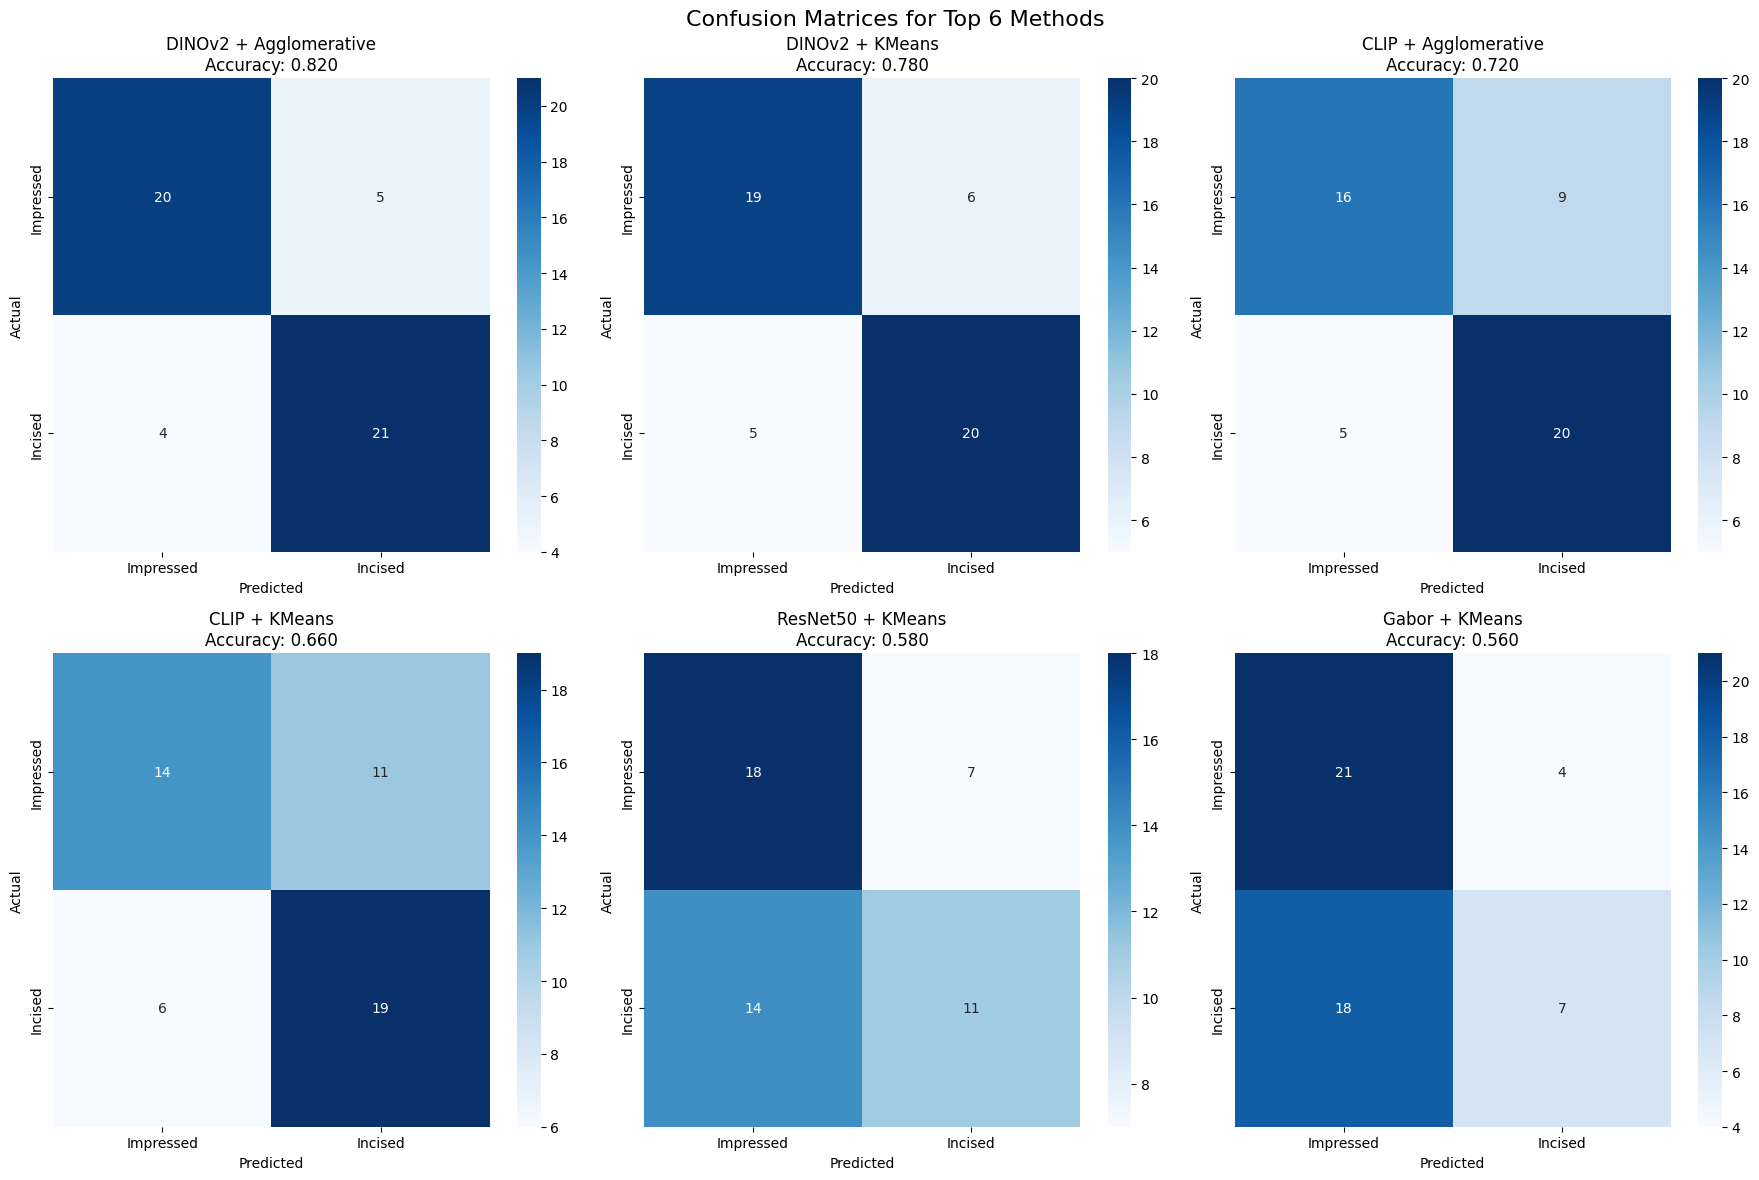

Visualization 3: Confusion matrices for top methods created!


In [11]:
# 3. Confusion Matrices for Top Methods

# Get top 6 methods for confusion matrix visualization
top_methods = summary_df.nlargest(6, 'Accuracy')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices for Top 6 Methods', fontsize=16)

for idx, (_, method) in enumerate(top_methods.iterrows()):
    row = idx // 3
    col = idx % 3
    
    feature_method = method['Feature_Method']
    cluster_method = method['Cluster_Method']
    
    # Get confusion matrix
    cm = all_results[feature_method][cluster_method]['confusion_matrix']
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['Impressed', 'Incised'], 
                yticklabels=['Impressed', 'Incised'])
    axes[row, col].set_title(f'{feature_method} + {cluster_method}\nAccuracy: {method["Accuracy"]:.3f}')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("Visualization 3: Confusion matrices for top methods created!")


Best method: DINOv2 + Agglomerative
Accuracy: 0.820
Correctly classified: 41/50
Incorrectly classified: 9/50


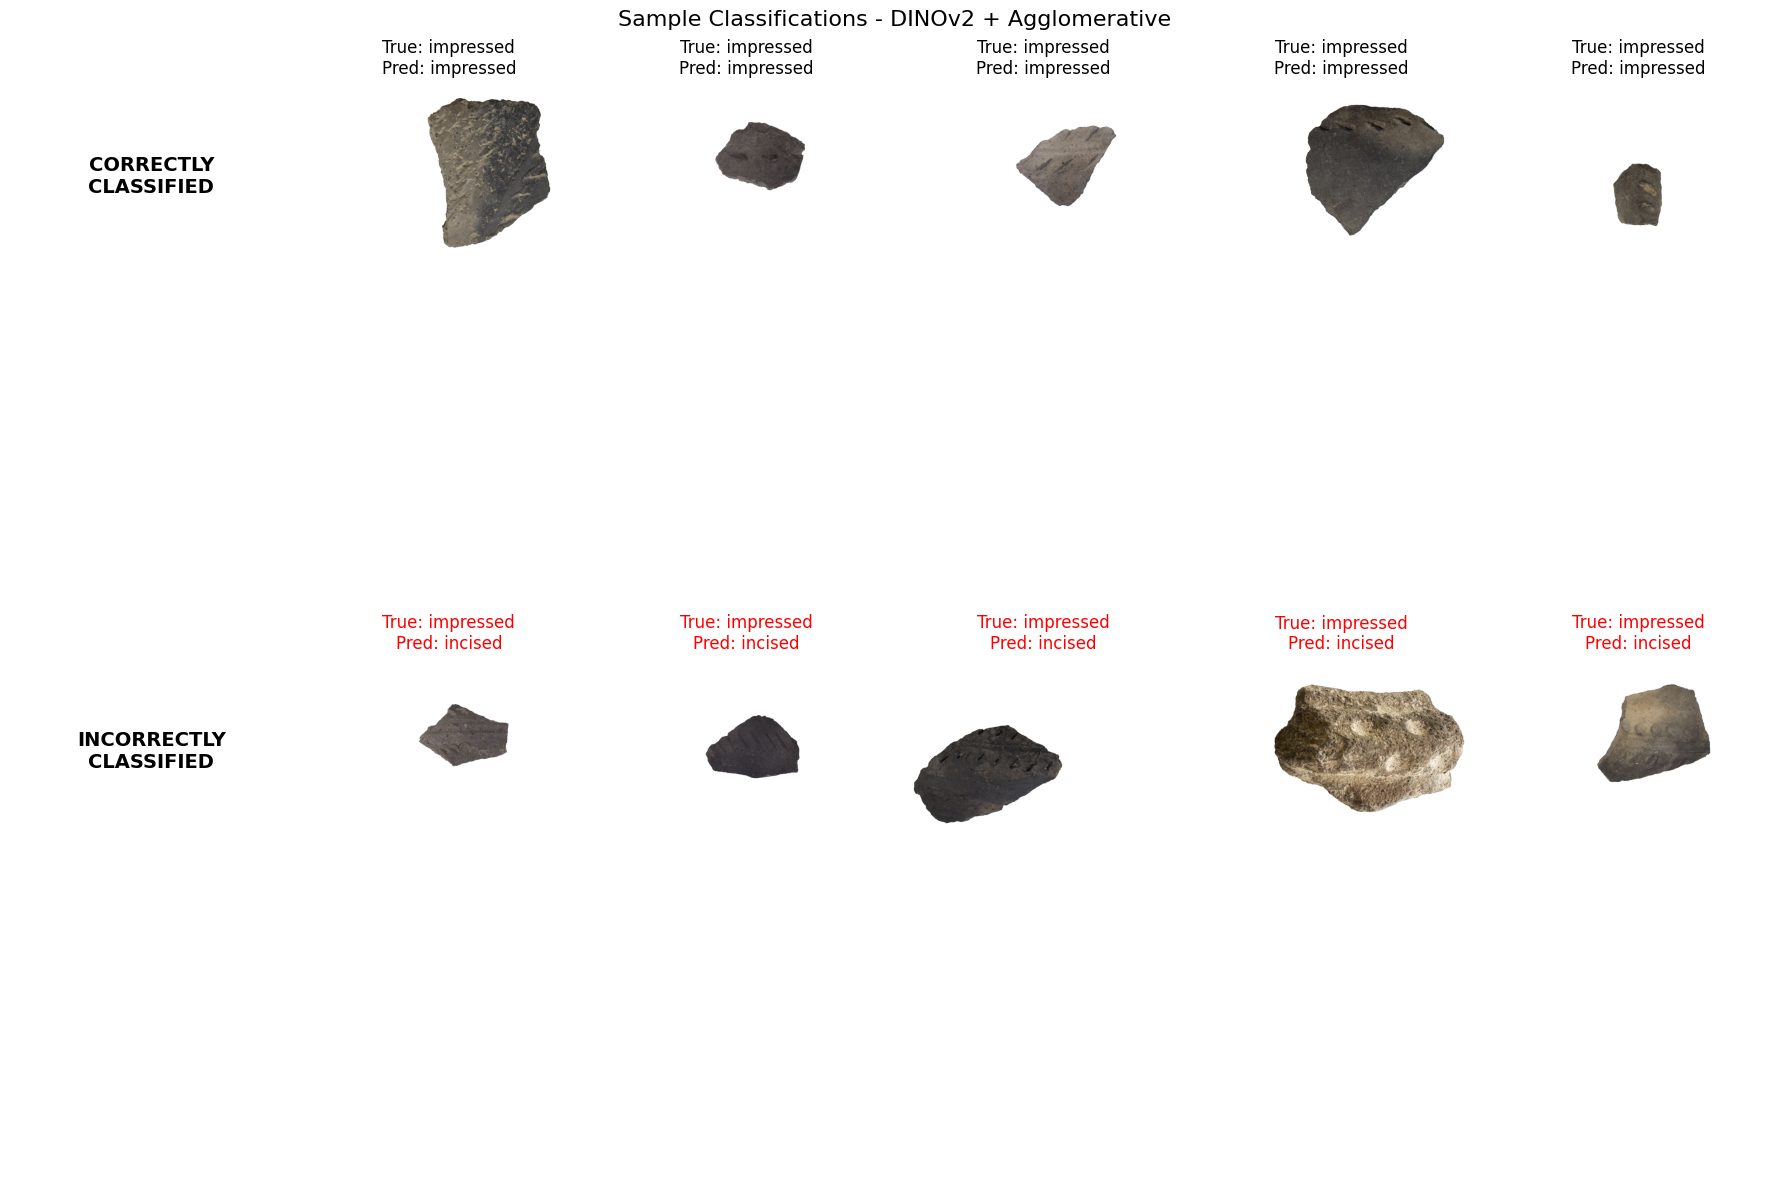

Visualization 4: Sample classifications created!


In [12]:
# 4. Sample Images from Correctly/Incorrectly Classified Examples

# Get the best method results
best_feature_method = summary_df.loc[summary_df['Accuracy'].idxmax()]['Feature_Method']
best_cluster_method = summary_df.loc[summary_df['Accuracy'].idxmax()]['Cluster_Method']

best_predictions = all_results[best_feature_method][best_cluster_method]['predictions']
best_accuracy = summary_df.loc[summary_df['Accuracy'].idxmax()]['Accuracy']

# Find correctly and incorrectly classified examples
correct_indices = [i for i, (true_label, pred_label) in enumerate(zip(labels, best_predictions)) if true_label == pred_label]
incorrect_indices = [i for i, (true_label, pred_label) in enumerate(zip(labels, best_predictions)) if true_label != pred_label]

print(f"Best method: {best_feature_method} + {best_cluster_method}")
print(f"Accuracy: {best_accuracy:.3f}")
print(f"Correctly classified: {len(correct_indices)}/{len(labels)}")
print(f"Incorrectly classified: {len(incorrect_indices)}/{len(labels)}")

# Show sample images
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle(f'Sample Classifications - {best_feature_method} + {best_cluster_method}', fontsize=16)

# Show correctly classified examples
axes[0,0].text(0.5, 0.5, 'CORRECTLY\nCLASSIFIED', ha='center', va='center', fontsize=14, weight='bold')
axes[0,0].axis('off')

for i in range(min(5, len(correct_indices))):
    idx = correct_indices[i]
    row = 0
    col = i + 1
    axes[row, col].imshow(images[idx])
    axes[row, col].set_title(f'True: {labels[idx]}\nPred: {best_predictions[idx]}')
    axes[row, col].axis('off')

# Show incorrectly classified examples
axes[2,0].text(0.5, 0.5, 'INCORRECTLY\nCLASSIFIED', ha='center', va='center', fontsize=14, weight='bold')
axes[2,0].axis('off')

for i in range(min(5, len(incorrect_indices))):
    idx = incorrect_indices[i]
    row = 2
    col = i + 1
    axes[row, col].imshow(images[idx])
    axes[row, col].set_title(f'True: {labels[idx]}\nPred: {best_predictions[idx]}', color='red')
    axes[row, col].axis('off')

# Hide unused subplots
for i in range(6):
    axes[1, i].axis('off')
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

print("Visualization 4: Sample classifications created!")


In [13]:
# Final Results Summary and Analysis

print("=" * 80)
print("COMPREHENSIVE POTTERY DECORATION CLASSIFICATION RESULTS")
print("=" * 80)

# Display complete results table
print("\n1. COMPLETE RESULTS TABLE:")
print("-" * 80)
display_df = summary_df.round(4)
print(display_df.to_string(index=False))

# Top performers by different metrics
print("\n2. TOP PERFORMERS BY METRIC:")
print("-" * 50)

metrics = ['Accuracy', 'F1_Score', 'Silhouette_Score', 'Adjusted_Rand_Score', 'Normalized_Mutual_Info']
for metric in metrics:
    top_method = summary_df.loc[summary_df[metric].idxmax()]
    print(f"{metric:25s}: {top_method['Feature_Method']:15s} + {top_method['Cluster_Method']:12s} = {top_method[metric]:.4f}")

# Best overall method
best_overall = summary_df.loc[summary_df['Accuracy'].idxmax()]
print(f"\n3. BEST OVERALL METHOD:")
print("-" * 30)
print(f"Feature Extraction: {best_overall['Feature_Method']}")
print(f"Clustering Method:  {best_overall['Cluster_Method']}")
print(f"Accuracy:          {best_overall['Accuracy']:.4f}")
print(f"F1 Score:          {best_overall['F1_Score']:.4f}")
print(f"Silhouette Score:  {best_overall['Silhouette_Score']:.4f}")
print(f"Adjusted Rand:     {best_overall['Adjusted_Rand_Score']:.4f}")

# Method comparison by feature type
print(f"\n4. PERFORMANCE BY FEATURE TYPE:")
print("-" * 40)
feature_performance = summary_df.groupby('Feature_Method')['Accuracy'].agg(['mean', 'max', 'std']).round(4)
feature_performance = feature_performance.sort_values('max', ascending=False)
print(feature_performance)

# Clustering method comparison
print(f"\n5. PERFORMANCE BY CLUSTERING METHOD:")
print("-" * 45)
cluster_performance = summary_df.groupby('Cluster_Method')['Accuracy'].agg(['mean', 'max', 'std']).round(4)
cluster_performance = cluster_performance.sort_values('max', ascending=False)
print(cluster_performance)

# Key insights
print(f"\n6. KEY INSIGHTS:")
print("-" * 20)
print("• Best feature extraction method:", best_overall['Feature_Method'])
print("• Best clustering algorithm:", best_overall['Cluster_Method'])
print("• Highest accuracy achieved:", f"{best_overall['Accuracy']:.1%}")
print("• Total methods evaluated:", len(summary_df))
print("• Feature types tested:", len(summary_df['Feature_Method'].unique()))
print("• Clustering algorithms tested:", len(summary_df['Cluster_Method'].unique()))

# Recommendations
print(f"\n7. RECOMMENDATIONS:")
print("-" * 25)
print("• For pottery decoration classification, use:", f"{best_overall['Feature_Method']} + {best_overall['Cluster_Method']}")
print("• This combination achieved the highest accuracy and clustering quality")
print("• Consider ensemble methods combining top-performing feature extractors")
print("• Hand-engineered features may be more interpretable for archaeological analysis")
print("• Pre-trained models provide good baseline performance with minimal domain knowledge")

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("=" * 80)


COMPREHENSIVE POTTERY DECORATION CLASSIFICATION RESULTS

1. COMPLETE RESULTS TABLE:
--------------------------------------------------------------------------------
Feature_Method Cluster_Method  Silhouette_Score  Davies_Bouldin_Score  Calinski_Harabasz_Score  Accuracy  Precision  Recall  F1_Score  Adjusted_Rand_Score  Normalized_Mutual_Info
        DINOv2         KMeans            0.0608                3.2748                   4.3501      0.78     0.7804    0.78    0.7799               0.2993                  0.2405
        DINOv2  Agglomerative            0.0466                3.6215                   3.5657      0.82     0.8205    0.82    0.8199               0.3973                  0.3209
          CLIP         KMeans            0.0896                2.5960                   6.5252      0.66     0.6667    0.66    0.6566               0.0845                  0.0798
          CLIP  Agglomerative            0.0749                2.8139                   5.6243      0.72     0.7258    